In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import torch
import numpy as np
from model import WaveFunctionNN, train, predicted
from prepare_data import get_dataloader_from_csv_file, extract_t_and_y_from_loader
from draw_with_plot import plot_data_and_predicted, draw_t_distribution
import pandas as pd

In [21]:
SEED = 42
BATCH_SIZE = 100
HIDDEN_SIZE = 128
NUM_LAYERS = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 400

LR = 0.05

torch.manual_seed(42)
print(f"device: {DEVICE}")

device: cuda


In [22]:
train_loader, eval_loader, scaler = get_dataloader_from_csv_file('finance.csv', ['t'], ['y'], BATCH_SIZE)

model = WaveFunctionNN(HIDDEN_SIZE, NUM_LAYERS)

best_loss = train(model, train_loader, eval_loader, EPOCHS, LR, DEVICE, eval_method='grid')


Starting training on cuda for 400 epochs...
Gradient clipping enabled with max norm = 5.0
Epoch 1: New best composite score: 159.766160 → Model saved!
Epoch [1/400] | Train Loss: 5717.894131 | Schrodinger: 0.000000 | Obs: -0.703191 | Norm: 5718.597267 | Grad Norm: 139485.5542 | Eval MAE: 16.807107 | Composite: 159.766160 | LR: 0.050000
Epoch 2: New best composite score: 97.890180 → Model saved!
Epoch [2/400] | Train Loss: 1199.179665 | Schrodinger: 0.000000 | Obs: -0.449538 | Norm: 1199.629201 | Grad Norm: 15323.5496 | Eval MAE: 16.525094 | Composite: 97.890180 | LR: 0.050000
Epoch 4: New best composite score: 86.945096 → Model saved!
Epoch [4/400] | Train Loss: 230.687049 | Schrodinger: 0.000000 | Obs: 0.237314 | Norm: 230.449735 | Grad Norm: 4723.7355 | Eval MAE: 17.007820 | Composite: 86.945096 | LR: 0.050000
Epoch 5: New best composite score: 85.573010 → Model saved!
Epoch [5/400] | Train Loss: 124.110188 | Schrodinger: 0.000000 | Obs: 0.576554 | Norm: 123.533633 | Grad Norm: 2600.

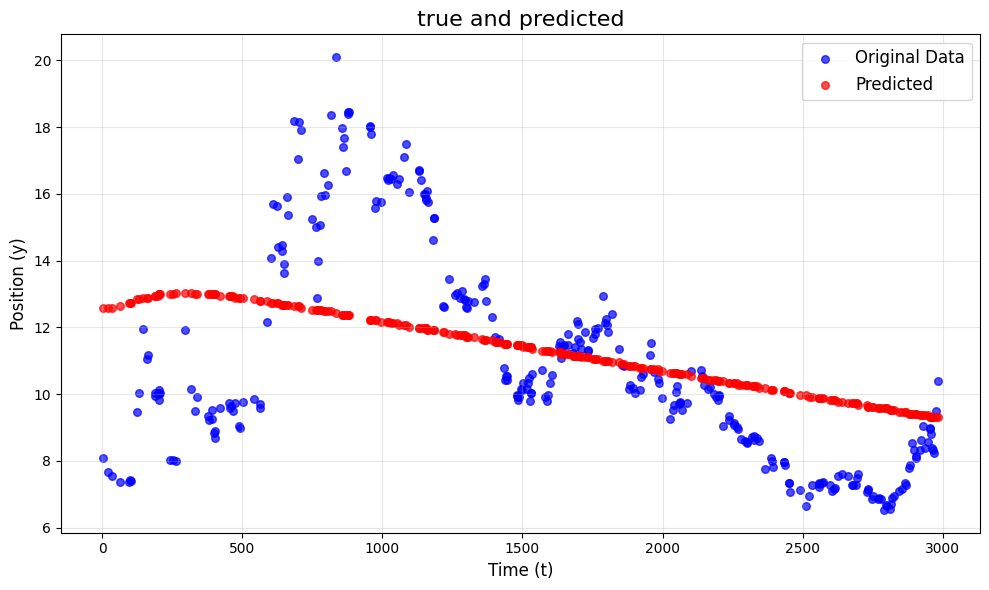

In [23]:
model.load_state_dict(torch.load('models_pth/best_model.pth'))

t, original_x = extract_t_and_y_from_loader(eval_loader)

predicted_t = torch.tensor(t.reshape(-1, 1)).to(DEVICE)
predicted_x = predicted(model, predicted_t, DEVICE)

predicted_t = predicted_t.cpu().numpy()
predicted_x = scaler.inverse_transform(predicted_x.cpu().numpy())

original_x = scaler.inverse_transform(original_x.reshape(-1, 1))

predicted_data = pd.DataFrame({'t': predicted_t.reshape(-1), 'y': predicted_x.reshape(-1)})
original_data = pd.DataFrame({'t': t.reshape(-1), 'y': original_x.reshape(-1)})

plot_data_and_predicted("true and predicted", original_data, predicted_data)

In [24]:
predicted_data.to_csv('predicted_with_no_schrodinger.csv', index=False)